# CS111 Project Template — 2D Heat Equation with Visualization

We solve the 2D heat equation on a square domain:

$$u_t = \kappa \Delta u$$

where $u(x,y,t)$ is temperature and $\kappa > 0$ is the diffusion coefficient.

This notebook is a **guided project template**. The goal is to build a 2D PDE solver step by step and visualize heat spreading over time.


## From Poisson to heat

In class, Poisson's equation was a **steady-state** diffusion problem:

$$-\Delta u = f.$$

The heat equation is the **time-dependent** version:

$$u_t = \kappa \Delta u.$$

So we keep the same Laplacian operator, but now the temperature changes over time.

That means we need:

1. a spatial discretization for the Laplacian
2. a time-stepping method
3. visualization of the evolving solution


## Big picture of the algorithm

We will:

1. build a 2D grid
2. flatten the grid into a vector
3. build the discrete Laplacian matrix
4. define an initial temperature field
5. implement **explicit Euler**
6. implement **implicit Euler**
7. compare stability and smoothing
8. visualize the temperature over time

The main scientific computing lesson is:

- the **same spatial operator** can be used with different time-stepping schemes
- explicit methods are simple but have stability restrictions
- implicit methods are more stable but require solving a linear system


## Step 0 — Imports


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.sparse import diags, eye, kron
from scipy.sparse.linalg import factorized


## Step 1 — Set up the spatial grid

We work on the square domain $[0,1]\times[0,1]$ with an $n\times n$ grid.

We will use **homogeneous Dirichlet boundary conditions**:

$$u = 0 \quad \text{on the boundary}.$$

So the edges are held at zero temperature.


In [2]:
n = 60
x = np.linspace(0.0, 1.0, n)
y = np.linspace(0.0, 1.0, n)
hx = x[1] - x[0]
hy = y[1] - y[0]

kappa = 0.02

X, Y = np.meshgrid(x, y, indexing='xy')

print('Grid size:', n, 'x', n)
print('hx =', hx)
print('hy =', hy)


Grid size: 60 x 60
hx = 0.01694915254237288
hy = 0.01694915254237288


## Step 2 — Build the 1D Laplacian

For interior points in 1D, the second derivative is approximated by

$$u_{xx}(x_i) \approx \frac{u_{i+1} - 2u_i + u_{i-1}}{h^2}.$$

This gives a tridiagonal matrix.

### Your task

Implement a function that builds the 1D finite-difference Laplacian.


In [3]:
def laplacian_1d(n, h):
    """Return the 1D finite-difference Laplacian matrix."""
    main = -2.0 * np.ones(n)
    off = np.ones(n - 1)
    L = diags([off, main, off], offsets=[-1, 0, 1], format='csc') / (h**2)
    return L


## Step 3 — Build the 2D Laplacian

In 2D,

$$\Delta u = u_{xx} + u_{yy}.$$

If we flatten the grid into a vector, the 2D Laplacian matrix can be built from the 1D Laplacian using Kronecker products:

$$L_{2D} = I \otimes L_{1D} + L_{1D} \otimes I.$$

### Your task

Implement a function for the 2D Laplacian.


In [4]:
def laplacian_2d(n, h):
    """Return the 2D finite-difference Laplacian matrix on an n x n grid."""
    L1 = laplacian_1d(n, h)
    I = eye(n, format='csc')
    L2 = kron(I, L1) + kron(L1, I)
    return L2.tocsc()


In [5]:
L = laplacian_2d(n, hx)
print('2D Laplacian shape:', L.shape)
print('Number of nonzeros:', L.nnz)


2D Laplacian shape: (3600, 3600)
Number of nonzeros: 17760


## Step 4 — Initial condition

We need an initial temperature field $u(x,y,0)$.

A good starting choice is a hot Gaussian blob in the center. You can also try multiple hot spots later.

### Your task

Implement an initial condition function that returns an $n\times n$ array.


In [6]:
def initial_condition(X, Y):
    """Return the initial temperature field on the grid."""
    u0 = np.exp(-80.0 * ((X - 0.5)**2 + (Y - 0.5)**2))
    return u0


u0 = initial_condition(X, Y)


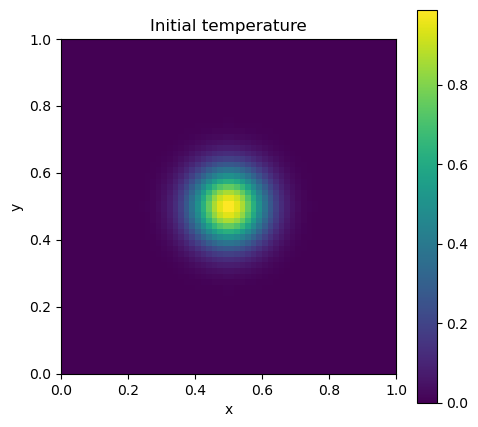

In [7]:
plt.figure(figsize=(5, 4.5))
plt.imshow(u0, origin='lower', extent=[0,1,0,1])
plt.title('Initial temperature')
plt.xlabel('x')
plt.ylabel('y')
plt.colorbar()
plt.tight_layout()
plt.show()


## Step 5 — Flattening and reshaping

The sparse matrix acts on vectors, not 2D arrays.

So we need helper functions to move between:

- a 2D grid array of shape `(n, n)`
- a 1D vector of length `n*n`

### Your task

Implement flatten/reshape helpers.


In [8]:
def flatten_field(U):
    """Convert an n x n array into a vector."""
    return U.ravel()


def reshape_field(u, n):
    """Convert a vector back into an n x n array."""
    return u.reshape((n, n))


## Step 6 — Explicit Euler time stepping

The heat equation is

$$u_t = \kappa L u.$$

Explicit Euler gives

$$u^{n+1} = u^n + \Delta t \, \kappa L u^n.$$

This is easy to implement, but it can become unstable if $\Delta t$ is too large.

### Your task

Implement one explicit Euler step.


In [9]:
def explicit_step(u, L, kappa, dt):
    """Take one explicit Euler step for the heat equation."""
    return u + dt * kappa * (L @ u)


## Step 7 — Implicit Euler time stepping

Implicit Euler gives

$$\frac{u^{n+1}-u^n}{\Delta t} = \kappa L u^{n+1}.$$

Rearrange:

$$(I - \Delta t\,\kappa L)u^{n+1} = u^n.$$

So the implicit method requires solving a linear system at every step.

Because the matrix does not change in time, we can factor it once and reuse the factorization.

### Your task

Build the implicit system matrix and its reusable solver.


In [10]:
def build_implicit_solver(L, kappa, dt):
    """Build and factor the implicit Euler system matrix."""
    N = L.shape[0]
    A = (eye(N, format='csc') - dt * kappa * L).tocsc()
    solve = factorized(A)
    return solve


In [11]:
def implicit_step(u, solve):
    """Take one implicit Euler step using a pre-factored solver."""
    return solve(u)


## Step 8 — Boundary conditions

Our matrix currently includes boundary points as unknowns too.

To keep this project simple, after every timestep we enforce

$$u=0 \quad \text{on the boundary}.$$

That means setting the edge values of the 2D grid to zero before continuing.

### Your task

Implement a helper that enforces zero boundary values.


In [12]:
def enforce_dirichlet_zero(U):
    """Set boundary values of U to zero."""
    U = U.copy()
    U[0, :] = 0.0
    U[-1, :] = 0.0
    U[:, 0] = 0.0
    U[:, -1] = 0.0
    return U


## Step 9 — Run the explicit method

We evolve the temperature for several timesteps and store snapshots for plotting.

Try changing `dt_explicit`. If it is too large, the explicit method may become unstable.


In [13]:
dt_explicit = 0.0008
num_steps = 400
snapshot_steps = [0, 10, 50, 150, 399]

u = flatten_field(enforce_dirichlet_zero(u0))
explicit_snapshots = []

for step in range(num_steps):
    if step in snapshot_steps:
        explicit_snapshots.append((step, reshape_field(u, n).copy()))
    u = explicit_step(u, L, kappa, dt_explicit)
    U = enforce_dirichlet_zero(reshape_field(u, n))
    u = flatten_field(U)

if num_steps - 1 not in snapshot_steps:
    explicit_snapshots.append((num_steps - 1, reshape_field(u, n).copy()))


## Step 10 — Visualize explicit Euler

This should show the hot spot diffusing outward and flattening over time.


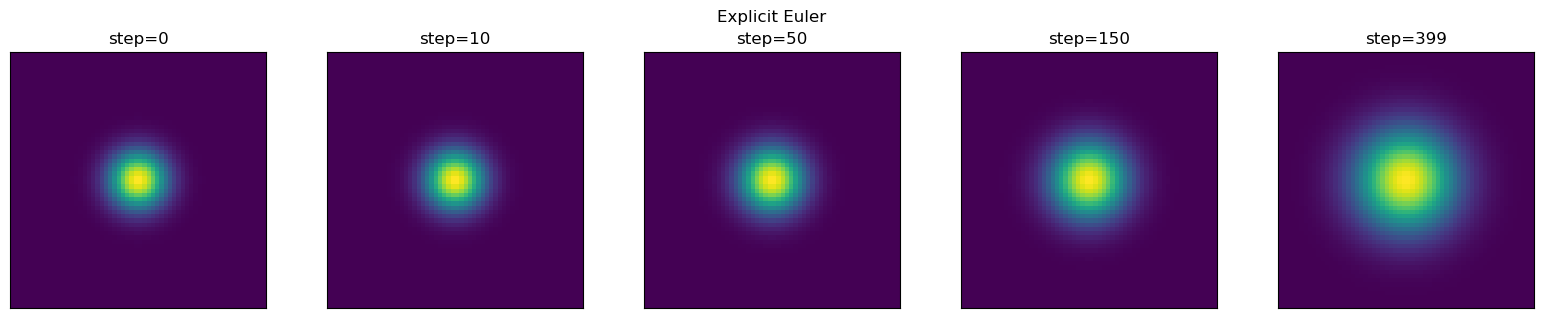

In [14]:
fig, axes = plt.subplots(1, len(explicit_snapshots), figsize=(3.2 * len(explicit_snapshots), 3.2))

for ax, (step, U) in zip(axes, explicit_snapshots):
    im = ax.imshow(U, origin='lower', extent=[0,1,0,1])
    ax.set_title(f'step={step}')
    ax.set_xticks([])
    ax.set_yticks([])

fig.suptitle('Explicit Euler')
plt.tight_layout()
plt.show()


## Step 11 — Run the implicit method

Now we repeat the experiment with implicit Euler.

Because implicit Euler is more stable, we can typically use a larger timestep.


In [15]:
dt_implicit = 0.01
solve_impl = build_implicit_solver(L, kappa, dt_implicit)

u = flatten_field(enforce_dirichlet_zero(u0))
implicit_snapshots = []

for step in range(num_steps):
    if step in snapshot_steps:
        implicit_snapshots.append((step, reshape_field(u, n).copy()))
    u = implicit_step(u, solve_impl)
    U = enforce_dirichlet_zero(reshape_field(u, n))
    u = flatten_field(U)

if num_steps - 1 not in snapshot_steps:
    implicit_snapshots.append((num_steps - 1, reshape_field(u, n).copy()))


## Step 12 — Visualize implicit Euler

Compare these plots to the explicit ones. The implicit method should remain stable even for larger timesteps.


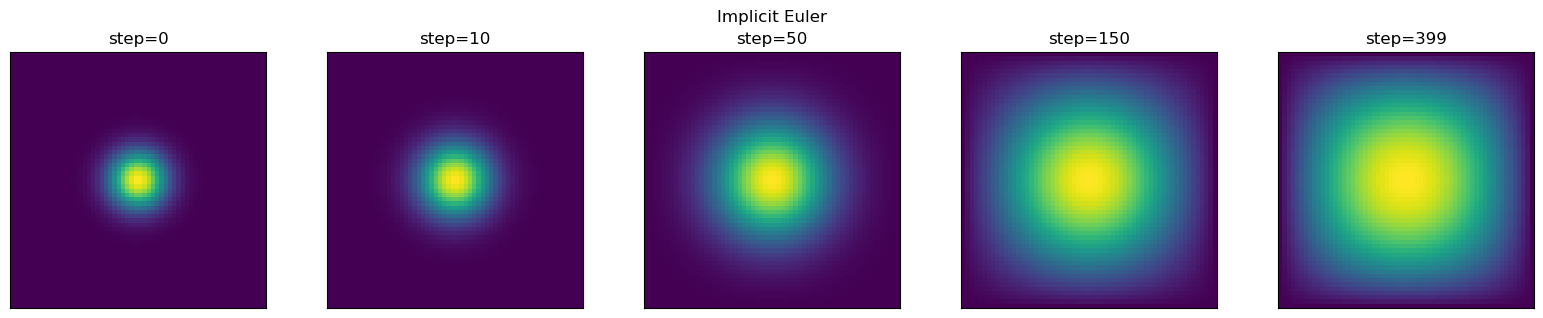

In [16]:
fig, axes = plt.subplots(1, len(implicit_snapshots), figsize=(3.2 * len(implicit_snapshots), 3.2))

for ax, (step, U) in zip(axes, implicit_snapshots):
    im = ax.imshow(U, origin='lower', extent=[0,1,0,1])
    ax.set_title(f'step={step}')
    ax.set_xticks([])
    ax.set_yticks([])

fig.suptitle('Implicit Euler')
plt.tight_layout()
plt.show()


## Step 13 — Compare explicit and implicit final states

This helps you compare the two methods directly.


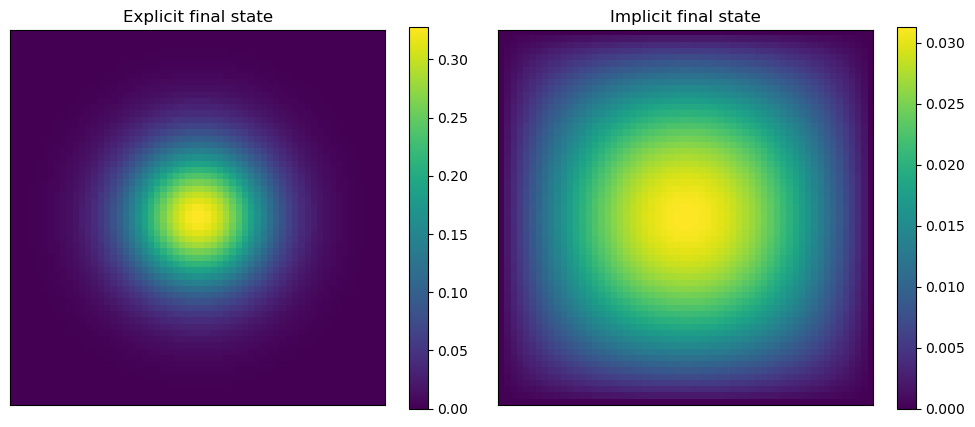

In [17]:
U_exp_final = explicit_snapshots[-1][1]
U_imp_final = implicit_snapshots[-1][1]

fig, axes = plt.subplots(1, 2, figsize=(10, 4.2))

im0 = axes[0].imshow(U_exp_final, origin='lower', extent=[0,1,0,1])
axes[0].set_title('Explicit final state')
axes[0].set_xticks([])
axes[0].set_yticks([])
plt.colorbar(im0, ax=axes[0])

im1 = axes[1].imshow(U_imp_final, origin='lower', extent=[0,1,0,1])
axes[1].set_title('Implicit final state')
axes[1].set_xticks([])
axes[1].set_yticks([])
plt.colorbar(im1, ax=axes[1])

plt.tight_layout()
plt.show()


## Step 14 — Optional animation-style sequence

This cell makes a longer sequence of snapshots for the implicit method.

You can use this as a basis for an animation or just scroll through the plots.


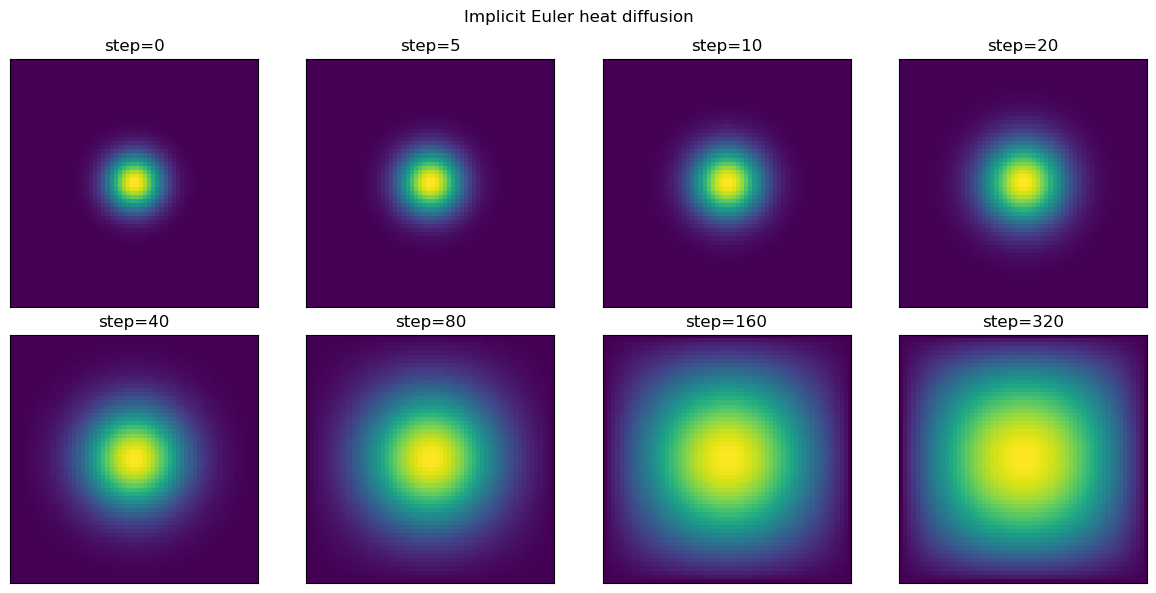

In [18]:
long_steps = [0, 5, 10, 20, 40, 80, 160, 320]
solve_impl = build_implicit_solver(L, kappa, dt_implicit)

u = flatten_field(enforce_dirichlet_zero(u0))
long_snapshots = []

for step in range(max(long_steps) + 1):
    if step in long_steps:
        long_snapshots.append((step, reshape_field(u, n).copy()))
    u = implicit_step(u, solve_impl)
    U = enforce_dirichlet_zero(reshape_field(u, n))
    u = flatten_field(U)

fig, axes = plt.subplots(2, 4, figsize=(12, 6))
axes = axes.ravel()

for ax, (step, U) in zip(axes, long_snapshots):
    ax.imshow(U, origin='lower', extent=[0,1,0,1])
    ax.set_title(f'step={step}')
    ax.set_xticks([])
    ax.set_yticks([])

fig.suptitle('Implicit Euler heat diffusion')
plt.tight_layout()
plt.show()


## Final summary

This notebook built a 2D heat solver step by step.

Key ideas:

- the Laplacian is the spatial diffusion operator
- explicit Euler is simple but can be unstable for large timesteps
- implicit Euler is more stable but requires solving a linear system
- the same PDE can be approached with different time-stepping methods

## Suggested project extensions

- try multiple hot spots in the initial condition
- test a much larger explicit timestep and observe instability
- vary `kappa` and compare diffusion speeds
- use a non-square heated region as the initial condition
- add a source term to model ongoing heating
- turn the snapshot sequence into a real animation
